# kaggle Compitition notebook

- Author : Nasik Rehman 
- linkIn:
- Github:
- twitter:


# survival Rate prediction by Neural Network in Tensorflow

In [8]:
pip install plotly


[notice] A new release of pip is available: 20.3.4 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
# import laibaries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import LabelEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error, root_mean_squared_error,r2_score

In [10]:
# load the data 
df_train = pd.read_csv("datasets/train.csv")  
df_test = pd.read_csv("datasets/test.csv")
submission = pd.read_csv("datasets/gender_submission.csv")

In [11]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [12]:
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [13]:
submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


# lets explore the data df_train.csv

In [14]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [15]:
(df_train.isnull().sum() / len(df_train) * 100).sort_values(ascending=False)    

Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
dtype: float64

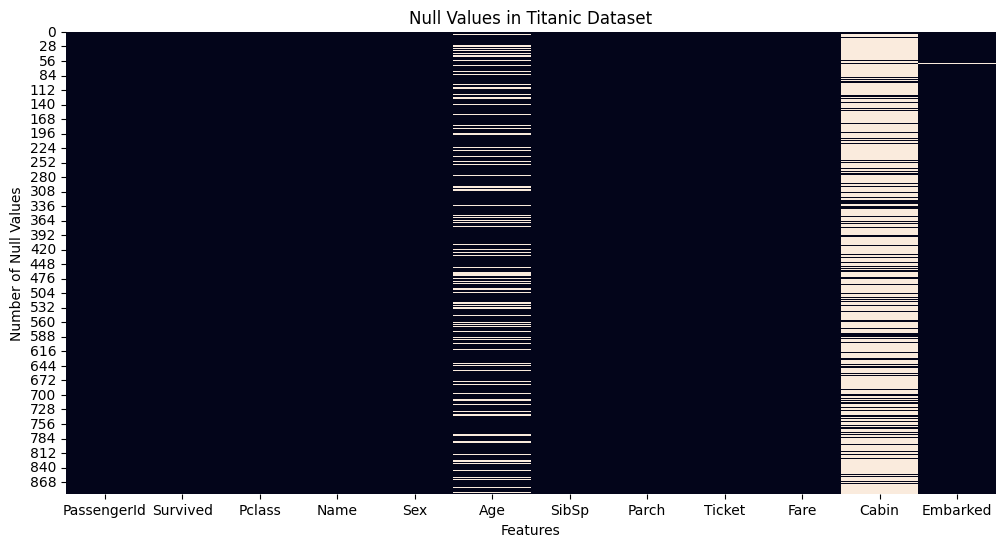

In [16]:
# plot the null values
plt.figure(figsize=(12, 6))
sns.heatmap(df_train.isnull(), cbar=False)
plt.title('Null Values in Titanic Dataset')
plt.xlabel('Features')
plt.ylabel('Number of Null Values')
plt.show()

In [17]:
df_train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [18]:
df_train.isnull().sum()[df_train.isnull().sum() > 0].sort_values(ascending=False)
missing_data_cols = df_train.isnull().sum()[df_train.isnull().sum() > 0].index.tolist()
missing_data_cols


['Age', 'Cabin', 'Embarked']

In [23]:
categorical_cols = ['Cabin', 'Embarked']
bool_cols = []
numeric_cols = ['Age']
# define the function to impute the missing values in thal column

def impute_categorical_missing_data(passed_col):
    
    df_null = df_train[df_train[passed_col].isnull()]
    df_not_null = df_train[df_train[passed_col].notnull()]

    X = df_not_null.drop(passed_col, axis=1)
    y = df_not_null[passed_col]
    
    other_missing_cols = [col for col in missing_data_cols if col != passed_col]
    
    label_encoder = LabelEncoder()

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])

    if passed_col in bool_cols:
        y = label_encoder.fit_transform(y)
        
    iterative_imputer = IterativeImputer(estimator=RandomForestRegressor(random_state=42), add_indicator=True)

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    rf_classifier = RandomForestClassifier()

    rf_classifier.fit(X_train, y_train)

    y_pred = rf_classifier.predict(X_test)

    acc_score = accuracy_score(y_test, y_pred)

    print("The feature '"+ passed_col+ "' has been imputed with", round((acc_score * 100), 2), "accuracy\n")

    X = df_null.drop(passed_col, axis=1)

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass
                
    if len(df_null) > 0: 
        df_null[passed_col] = rf_classifier.predict(X)
        if passed_col in bool_cols:
            df_null[passed_col] = df_null[passed_col].map({0: False, 1: True})
        else:
            pass
    else:
        pass

    df_combined = pd.concat([df_not_null, df_null])
    
    return df_combined[passed_col]

def impute_continuous_missing_data(passed_col):
    
    df_null = df_train[df_train[passed_col].isnull()]
    df_not_null = df_train[df_train[passed_col].notnull()]

    X = df_not_null.drop(passed_col, axis=1)
    y = df_not_null[passed_col]
    
    other_missing_cols = [col for col in missing_data_cols if col != passed_col]
    
    label_encoder = LabelEncoder()

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])
    
    iterative_imputer = IterativeImputer(estimator=RandomForestRegressor(random_state=42), add_indicator=True)

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    rf_regressor = RandomForestRegressor()

    rf_regressor.fit(X_train, y_train)

    y_pred = rf_regressor.predict(X_test)

    print("MAE =", mean_absolute_error(y_test, y_pred), "\n")
    print("RMSE =", root_mean_squared_error(y_test, y_pred), "\n")
    print("R2 =", r2_score(y_test, y_pred), "\n")

    X = df_null.drop(passed_col, axis=1)

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass
                
    if len(df_null) > 0: 
        df_null[passed_col] = rf_regressor.predict(X)
    else:
        pass

    df_combined = pd.concat([df_not_null, df_null])
    
    return df_combined[passed_col]

    # remove warning
import warnings
warnings.filterwarnings('ignore')

# impute missing values using our functions
for col in missing_data_cols:
    print("Missing Values", col, ":", str(round((df_train[col].isnull().sum() / len(df_train)) * 100, 2))+"%")
    if col in categorical_cols:
        df_train[col] = impute_categorical_missing_data(col)
    elif col in numeric_cols:
        df_train[col] = impute_continuous_missing_data(col)
    else:
        pass

Missing Values Age : 19.87%
MAE = 9.335231468531468 

RMSE = 11.601085013974707 

R2 = 0.2740985749114908 

Missing Values Cabin : 77.1%
The feature 'Cabin' has been imputed with 26.83 accuracy

Missing Values Embarked : 0.22%
The feature 'Embarked' has been imputed with 88.76 accuracy



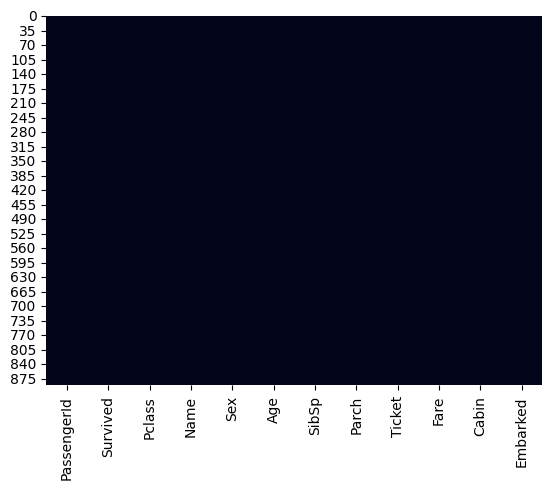

In [26]:
# plot missing values
sns.heatmap(df_train.isnull(), cbar=False)
plt.show()

Missing values have been imputed or removed from the dataset.

In [28]:
df_test.isnull().sum().sort_values(ascending=False)

Cabin          327
Age             86
Fare             1
PassengerId      0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Embarked         0
dtype: int64

In [33]:
# split the data into train and test
X = df_train.drop(['Survived','Name'], axis=1)
y = df_train['Survived']

# encode the data
label_encoder = LabelEncoder()
for col in X.columns:
    if X[col].dtype == 'object' or X[col].dtype == 'category':
        X[col] = label_encoder.fit_transform(X[col])

# split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # train the model
# rf_classifier = RandomForestClassifier()
# rf_classifier.fit(X_train, y_train)

# # make predictions
# y_pred = rf_classifier.predict(X_test)

# # evaluate the model
# print("Accuracy =", accuracy_score(y_test, y_pred))
# print("MAE =", mean_absolute_error(y_test, y_pred))
# print("RMSE =", root_mean_squared_error(y_test, y_pred))
# print("R2 =", r2_score(y_test, y_pred))


In [ ]:
# create a list of models to evaluate
models = [
    ('Random Forest', RandomForestClassifier(random_state=42)),
    ('Gradient Boosting', GradientBoostingClassifier(random_state=42)),
    ('Support Vector Machine', SVC(random_state=42)),
    ('Logistic Regression', LogisticRegression(random_state=42))
]

best_model = None
best_accuracy = 0.0

# iterate over the models and evaluate their performance
for name, model in models:
    # creat a pipeline for a each model 
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore')),
        ('model', model)
        ])
    # perform cross-validation                 
    scores = cross_val_score(pipeline, X_train, y_train, cv=5)

    # Calculate mean accuracy
    mean_accuracy = scores.mean()
    # fit the pipeline on the training data
    pipeline.fit(X_train, y_train)
    # make a prediction on training data 
    y_pred = pipeline.predict(X_test)
    # calculate accuracy score
    accuracy = accuracy_score(y_test, y_pred)
    # print the results
    print("Model:", name)
    print("Cross-validation Accuracy:", mean_accuracy)
    print("Test Accuracy:", accuracy)
    print()
    
    # check if the current model has the best accuracy
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = pipeline

# retrieve the best model 
print("Best Model:", best_model)

In [34]:
X_train.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
331,332,1,1,45.5,0,0,20,28.5000,56,2
733,734,2,1,23.0,0,0,228,13.0000,90,2
382,383,3,1,32.0,0,0,665,7.9250,115,2
704,705,3,1,26.0,1,0,398,7.8542,143,2
813,814,3,0,6.0,4,2,333,31.2750,20,2


# create a Neural Network for Binary Classification


Epoch 1/100
23/23 [==============================] - 8s 314ms/step - loss: 7.4999 - accuracy: 0.5421 - val_loss: 2.8677 - val_accuracy: 0.6201
Epoch 2/100
23/23 [==============================] - 0s 19ms/step - loss: 2.2367 - accuracy: 0.5899 - val_loss: 1.7664 - val_accuracy: 0.5475
Epoch 3/100
23/23 [==============================] - 0s 17ms/step - loss: 1.3920 - accuracy: 0.6138 - val_loss: 1.2221 - val_accuracy: 0.5307
Epoch 4/100
23/23 [==============================] - 0s 21ms/step - loss: 1.1370 - accuracy: 0.6152 - val_loss: 0.7288 - val_accuracy: 0.7318
Epoch 5/100
23/23 [==============================] - 0s 18ms/step - loss: 0.8418 - accuracy: 0.6124 - val_loss: 0.8344 - val_accuracy: 0.5866
Epoch 6/100
23/23 [==============================] - 0s 18ms/step - loss: 0.8447 - accuracy: 0.6306 - val_loss: 0.6594 - val_accuracy: 0.6592
Epoch 7/100
23/23 [==============================] - 0s 19ms/step - loss: 0.7705 - accuracy: 0.6713 - val_loss: 0.6376 - val_accuracy: 0.6760
Epoch

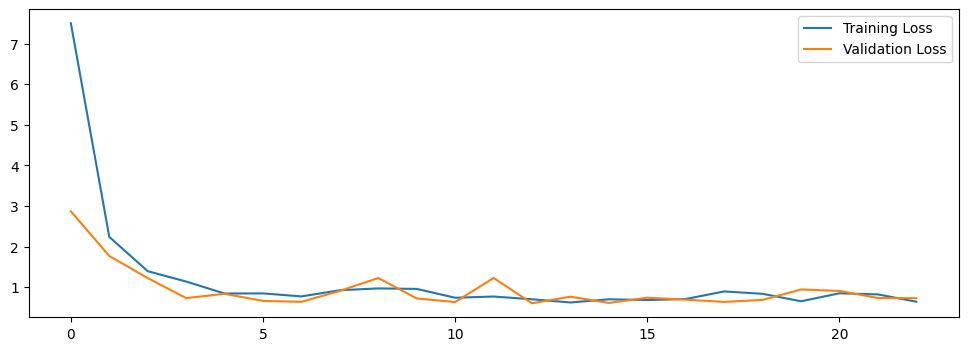

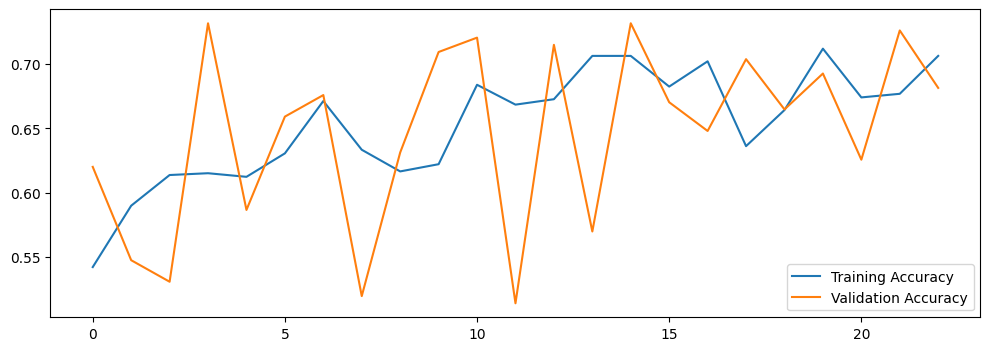

In [45]:
# use tenserflow to create a neural network model and EarlyStopping
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
# create a model
model = tf.keras.models.Sequential()

# add layers
model.add(tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(tf.keras.layers.Dense(32, activation='relu'))
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

# compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# define the early stopping callback
early_stopping = EarlyStopping(patience=10)


# train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=1, validation_data=(X_test, y_test), callbacks=[early_stopping])

# evaluate the model
loss = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss}")

# plot the loss and accuracy
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(history.history['loss'], label='Training Loss')
ax.plot(history.history['val_loss'], label='Validation Loss')
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(history.history['accuracy'], label='Training Accuracy')
ax.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax.legend()
plt.show()